Testing CNN model

In [29]:
import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd


from keras import Sequential, layers, callbacks, losses, utils, applications, Input
from keras.preprocessing import image_dataset_from_directory

Preprocess data and create the training and validation split 80% / 20%.

In [30]:
img_height = 224
img_width = 224

batch_size = 8

seed = 123

input_shape = [img_height,img_width, 3]
# 3 for rgb 
data_dir = "../data/tests/flower_photos"

split = 0.5

ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=split,
    seed=seed,
    subset="training",
    image_size=(img_height,img_width),
    batch_size=batch_size
    )
ds_valid= image_dataset_from_directory(
    data_dir,
    validation_split=split,
    seed=seed,
    subset="validation",
    image_size=(img_height,img_width),
    batch_size=batch_size
    )


class_names = ds_valid.class_names
num_classes = 5

Found 3670 files belonging to 5 classes.
Using 1835 files for training.
Found 3670 files belonging to 5 classes.
Using 1835 files for validation.


In [31]:
%%capture
for image_batch, labels_batch in ds_train:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

In [32]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_valid = ds_valid.cache().prefetch(buffer_size=AUTOTUNE)

In [33]:
#body = applications.VGG16()
#body.trainable = False

In [34]:

layers = [
    #body,
    layers.Conv2D(64,3, activation="relu", input_shape=input_shape),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3, activation="relu", input_shape=input_shape),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64,3, activation="relu", input_shape=input_shape),
    layers.MaxPooling2D(),
    
    
    # Classifier head
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
]

/home/paul/Desktop/projects/modelz/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model = Sequential(layers=layers)

early_stopping = callbacks.EarlyStopping(patience=5,
                                      min_delta=0.001,restore_best_weights=True)
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

Train the model

In [36]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │     1,384,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,460,293 (5.57 MB)

 Trainable params: 1,460,293 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
%%capture
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    callbacks=[early_stopping],
    epochs=40,
)

2025-12-28 17:53:44.215702: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,52,52]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,54,54]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-28 17:53:56.049119: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,52,52]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,54,54]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForwa

<Axes: >

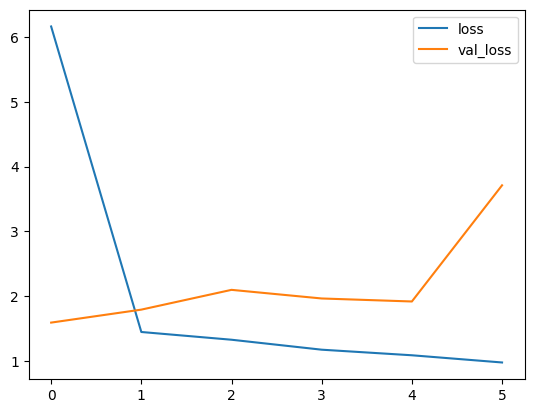

In [38]:

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()